# 🏥 Track 1: Clinical AI Assistant
## UVic Healthcare AI Hackathon — March 27-28, 2026

Welcome! This notebook will walk you through:
1. Loading and exploring synthetic clinical data (patients, encounters, labs, vitals, medications)
2. Exploratory data analysis (EDA) on patient demographics and encounter patterns
3. Building a triage prediction model (predict CTAS level from clinical features)
4. Ideas for extending your project

**Data:** All data is synthetic — generated to mimic patterns in BC healthcare. No real patient data is used.

**Time estimate:** 30–45 minutes to work through this notebook, then you’ll have a solid foundation to build on.

In [1]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import sys
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Add shared utilities to path
sys.path.insert(0, str(Path("../shared")))
from utilities import *

print("✅ Setup complete!")
print(f"📁 Data directory: {DEFAULT_DATA_DIR}")

✅ Setup complete!
📁 Data directory: DATA Location

---
## 📦 Load Data

Let’s start by getting an overview of all available datasets, then load the clinical data.

In [2]:
# Quick overview of all available data
dataset_overview()

  UVic Healthcare AI Hackathon - Dataset Overview

  Patients
   Rows: 2,000  |  Columns: 11  |  Size: 174 KB
   Columns: patient_id, first_name, last_name, date_of_birth, age, sex, postal_code, blood_type...

  Encounters
   Rows: 10,000  |  Columns: 12  |  Size: 1459 KB
   Columns: encounter_id, patient_id, encounter_date, encounter_type, facility, chief_complaint, diagnosis_code, diagnosis_description...

  Medications
   Rows: 5,000  |  Columns: 11  |  Size: 517 KB
   Columns: medication_id, patient_id, drug_name, drug_code, dosage, frequency, route, prescriber...

  Lab Results
   Rows: 3,000  |  Columns: 11  |  Size: 252 KB
   Columns: lab_id, patient_id, encounter_id, test_name, test_code, value, unit, reference_range_low...

  Vitals
   Rows: 2,000  |  Columns: 11  |  Size: 155 KB
   Columns: vitals_id, patient_id, encounter_id, heart_rate, systolic_bp, diastolic_bp, temperature_celsius, respiratory_rate...

  BC Health Indicators
   Rows: 78  |  Columns: 21  |  Size: 9 KB
   C

In [3]:
# Load all clinical datasets
patients = load_patients()
encounters = load_encounters()
medications = load_medications()
labs = load_labs()
vitals = load_vitals()

print(f"Patients:    {len(patients):,} records")
print(f"Encounters:  {len(encounters):,} records")
print(f"Medications: {len(medications):,} records")
print(f"Lab Results: {len(labs):,} records")
print(f"Vitals:      {len(vitals):,} records")

Patients:    2,000 records
Encounters:  10,000 records
Medications: 5,000 records
Lab Results: 3,000 records
Vitals:      2,000 records


In [4]:
# Preview patients
patients.head()

,patient_id,first_name,last_name,date_of_birth,age,sex,postal_code,blood_type,insurance_number,primary_language,emergency_contact_phone
0,PAT-000001,Margaret,Johnson,1974-09-22,51,F,V8S 6G3,O+,2074 916 154,English,1-133-218-1960
1,PAT-000002,Anna,Hall,2001-10-12,24,F,V8S 8E2,A-,1348 497 771,English,383-863-7940
2,PAT-000003,Michael,Peterson,1966-01-16,60,M,V8P 1V6,A+,2898 173 466,English,535 116 1559
3,PAT-000004,Renee,Blair,1962-11-01,63,F,V8P 0W4,A+,4501 941 332,English,(516) 184-9593 x103
4,PAT-000005,Victoria,Wyatt,2021-02-09,5,F,V8S 4N8,A+,9061 061 417,English,264.752.5534


In [5]:
# Preview encounters
encounters.head()

,encounter_id,patient_id,encounter_date,encounter_type,facility,chief_complaint,diagnosis_code,diagnosis_description,triage_level,disposition,length_of_stay_hours,attending_physician
0,ENC-0000001,PAT-000797,2024-10-28,outpatient,Royal Jubilee Hospital,nausea and vomiting,K21.0,Gastroesophageal reflux disease,2,discharged,0.0,Dr. Matthew Baldwin
1,ENC-0000002,PAT-001385,2025-03-21,emergency,Saanich Peninsula Hospital,cough and cold symptoms,J06.9,Acute upper respiratory infection,4,discharged,0.0,Dr. Andrew Erickson
2,ENC-0000003,PAT-001668,2023-04-12,outpatient,Royal Jubilee Hospital,dizziness,E11.9,Type 2 diabetes mellitus,3,discharged,0.0,Dr. Mark Wright
3,ENC-0000004,PAT-000573,2023-11-29,inpatient,Victoria General Hospital,headache,G43.9,Migraine,3,discharged,0.0,Dr. Gregory Wilson
4,ENC-0000005,PAT-000683,2025-08-24,emergency,Victoria General Hospital,back pain,M54.5,Low back pain,4,transferred,24.0,Dr. Jason Sandoval


---
## 📊 Patient Demographics

Let’s explore who our synthetic patients are — age, sex, blood type, location, and language.

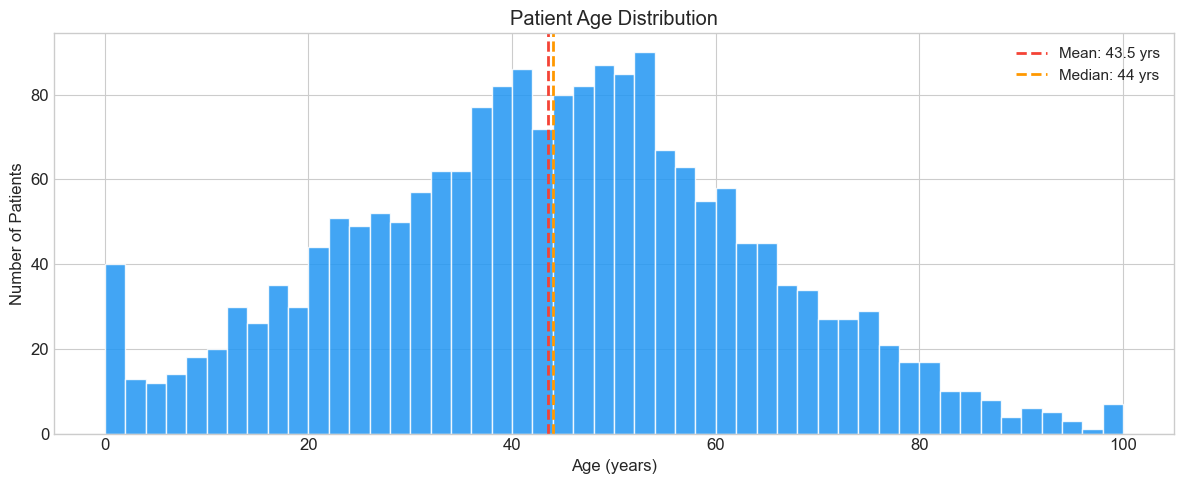

In [6]:
# Age distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(patients['age'], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
ax.axvline(patients['age'].mean(), color='#F44336', linestyle='--', linewidth=2,
           label=f"Mean: {patients['age'].mean():.1f} yrs")
ax.axvline(patients['age'].median(), color='#FF9800', linestyle='--', linewidth=2,
           label=f"Median: {patients['age'].median():.0f} yrs")
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Patients')
ax.set_title('Patient Age Distribution')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

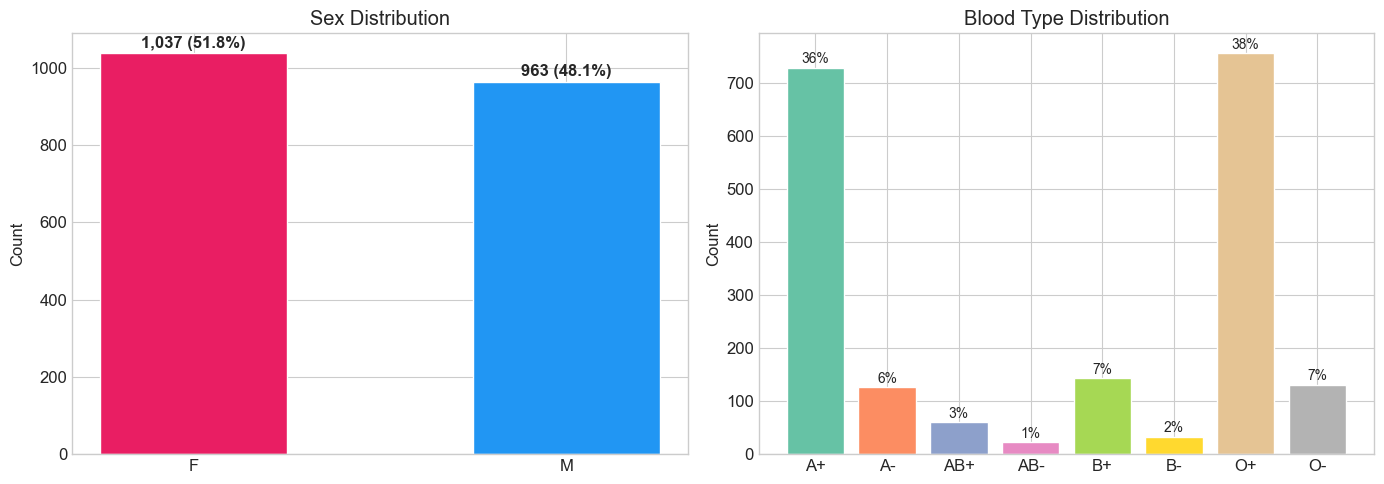

In [7]:
# Sex distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_counts = patients['sex'].value_counts()
colors_sex = ['#E91E63', '#2196F3']
axes[0].bar(sex_counts.index, sex_counts.values, color=colors_sex, edgecolor='white', width=0.5)
for i, (label, val) in enumerate(zip(sex_counts.index, sex_counts.values)):
    axes[0].text(i, val + 15, f"{val:,} ({val/len(patients)*100:.1f}%)",
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Sex Distribution')
axes[0].set_ylabel('Count')

# Blood type distribution
bt_counts = patients['blood_type'].value_counts().sort_index()
colors_bt = plt.cm.Set2(np.linspace(0, 1, len(bt_counts)))
axes[1].bar(bt_counts.index, bt_counts.values, color=colors_bt, edgecolor='white')
for i, (label, val) in enumerate(zip(bt_counts.index, bt_counts.values)):
    axes[1].text(i, val + 8, f"{val/len(patients)*100:.0f}%",
                 ha='center', fontsize=10)
axes[1].set_title('Blood Type Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

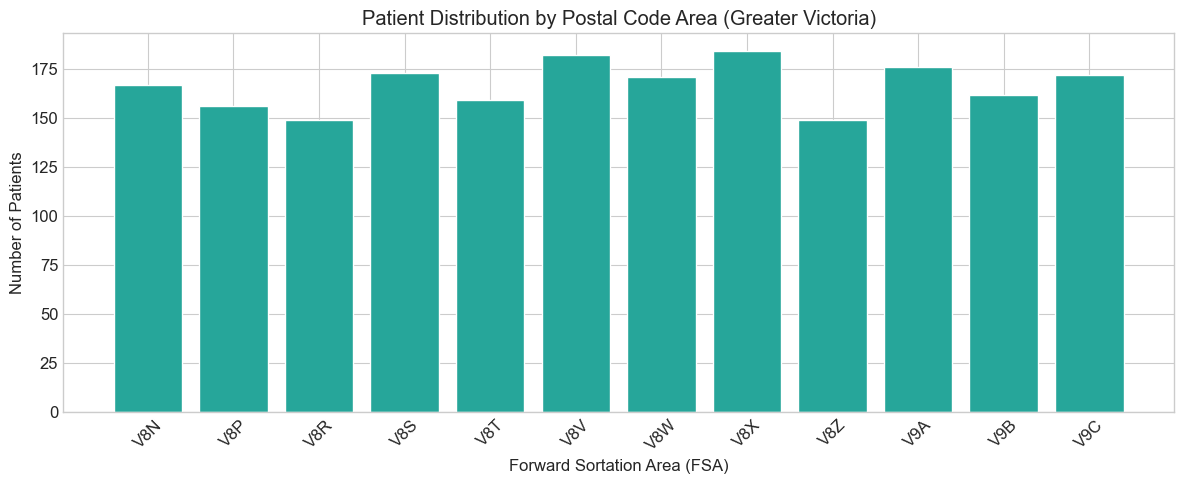

In [8]:
# Postal code (FSA) distribution — Greater Victoria
patients['fsa'] = patients['postal_code'].str[:3]
fsa_counts = patients['fsa'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(fsa_counts.index, fsa_counts.values, color='#26A69A', edgecolor='white')
ax.set_xlabel('Forward Sortation Area (FSA)')
ax.set_ylabel('Number of Patients')
ax.set_title('Patient Distribution by Postal Code Area (Greater Victoria)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

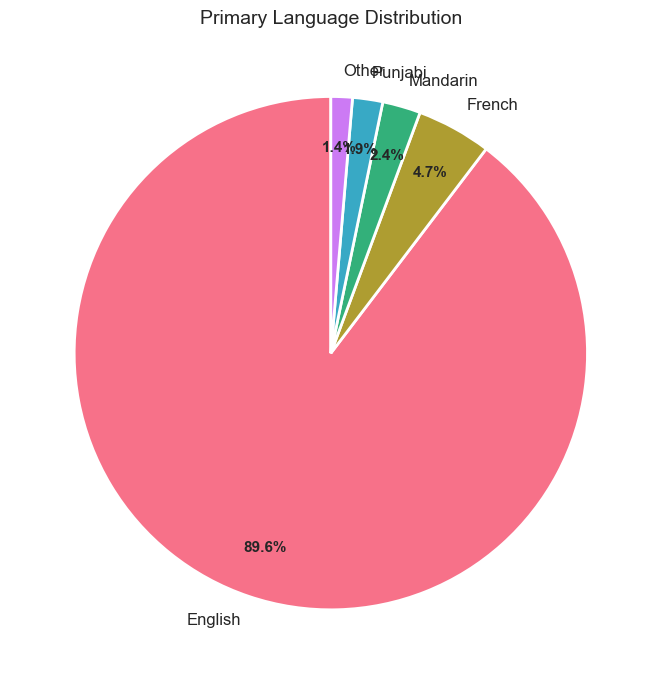

In [9]:
# Language distribution
lang_counts = patients['primary_language'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%',
    colors=sns.color_palette('husl', len(lang_counts)),
    startangle=90, pctdistance=0.8,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title('Primary Language Distribution', fontsize=14)
plt.tight_layout()
plt.show()

---
## 🏨 Encounter Analysis

Now let’s explore the 10,000 clinical encounters — when they happened, where, and what for.

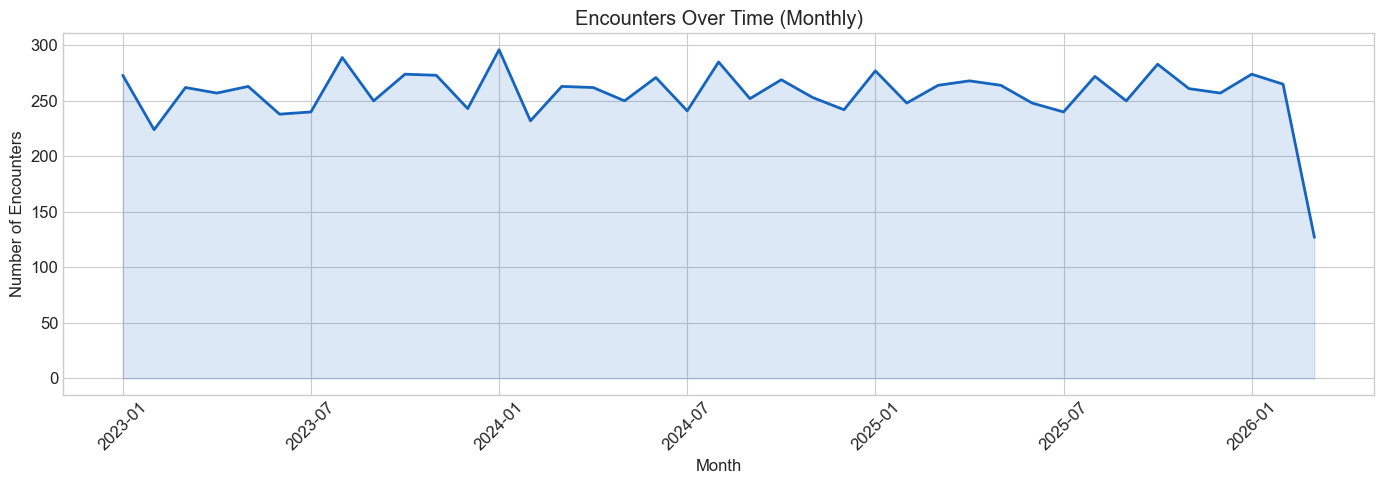

In [10]:
# Encounters over time (monthly)
encounters['month'] = encounters['encounter_date'].dt.to_period('M')
monthly = encounters.groupby('month').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index.astype(str), monthly.values, color='#1565C0', linewidth=2)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color='#1565C0')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Encounters')
ax.set_title('Encounters Over Time (Monthly)')
# Show only every 6th tick label to avoid crowding
tick_positions = range(0, len(monthly), 6)
ax.set_xticks(tick_positions)
ax.set_xticklabels([monthly.index.astype(str)[i] for i in tick_positions], rotation=45)
plt.tight_layout()
plt.show()

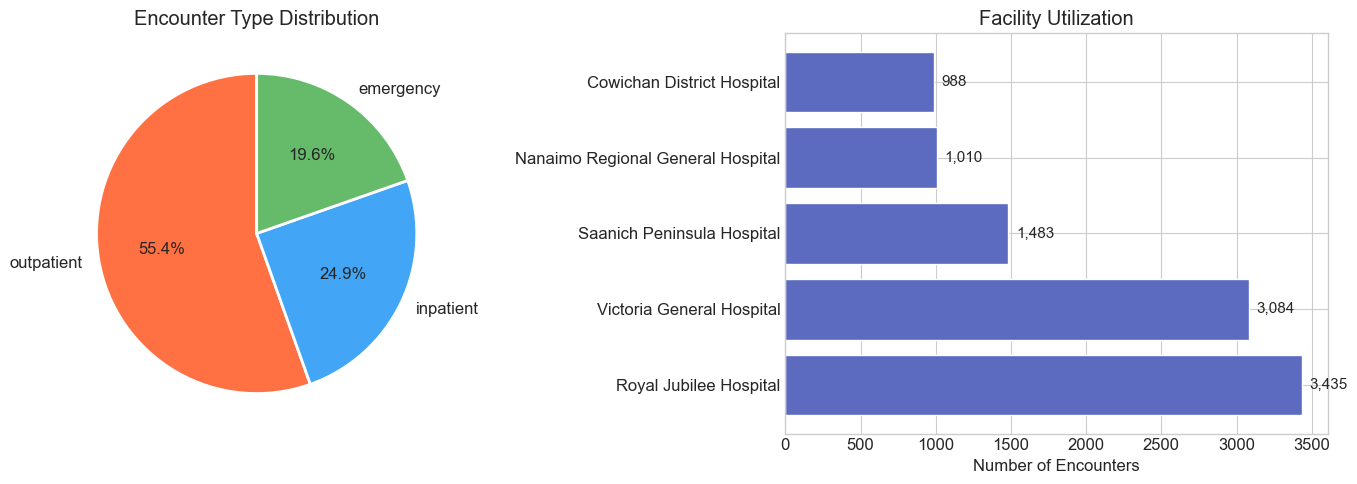

In [11]:
# Encounter type distribution
enc_type_counts = encounters['encounter_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_enc = ['#FF7043', '#42A5F5', '#66BB6A']
axes[0].pie(enc_type_counts.values, labels=enc_type_counts.index, autopct='%1.1f%%',
            colors=colors_enc, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Encounter Type Distribution')

# Facility utilization
fac_counts = encounters['facility'].value_counts()
axes[1].barh(fac_counts.index, fac_counts.values, color='#5C6BC0', edgecolor='white')
for i, val in enumerate(fac_counts.values):
    axes[1].text(val + 50, i, f"{val:,}", va='center', fontsize=11)
axes[1].set_xlabel('Number of Encounters')
axes[1].set_title('Facility Utilization')

plt.tight_layout()
plt.show()

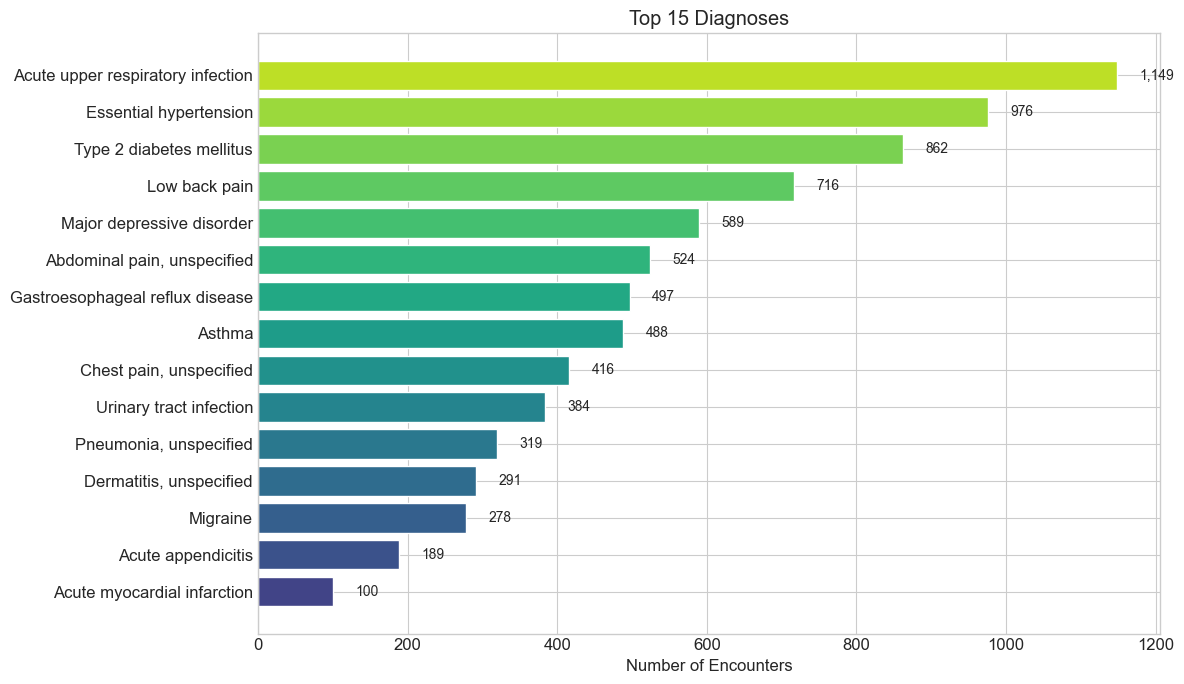

In [12]:
# Top 15 diagnoses
top_dx = encounters['diagnosis_description'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_dx.index[::-1], top_dx.values[::-1],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, 15)), edgecolor='white')
for bar, val in zip(bars, top_dx.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va='center', fontsize=10)
ax.set_xlabel('Number of Encounters')
ax.set_title('Top 15 Diagnoses')
plt.tight_layout()
plt.show()

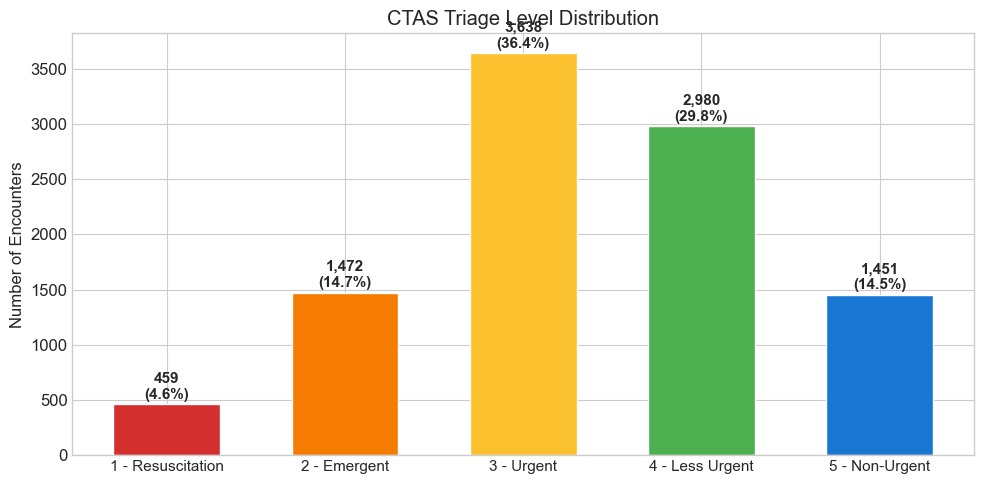

In [13]:
# CTAS triage level distribution
ctas_counts = encounters['triage_level'].value_counts().sort_index()
ctas_colors = ['#D32F2F', '#F57C00', '#FBC02D', '#4CAF50', '#1976D2']
ctas_labels = [
    '1 - Resuscitation', '2 - Emergent', '3 - Urgent',
    '4 - Less Urgent', '5 - Non-Urgent'
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(ctas_counts)), ctas_counts.values,
              color=ctas_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, ctas_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 50,
            f"{val:,}\n({val/len(encounters)*100:.1f}%)",
            ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(range(len(ctas_counts)))
ax.set_xticklabels(ctas_labels, fontsize=11)
ax.set_ylabel('Number of Encounters')
ax.set_title('CTAS Triage Level Distribution')
plt.tight_layout()
plt.show()

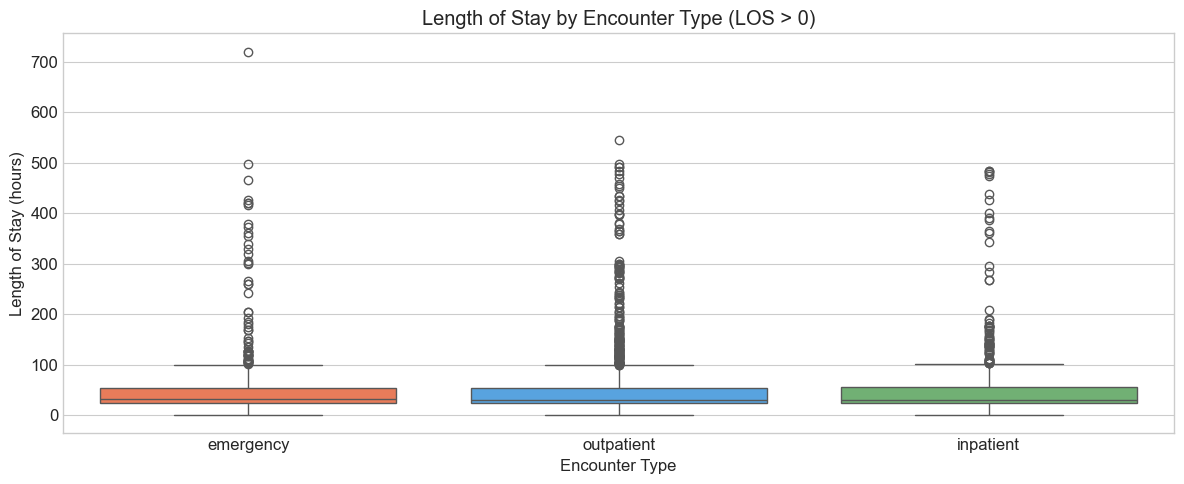

In [14]:
# Length of stay by encounter type (excluding discharged with 0 LOS for clarity)
los_data = encounters[encounters['length_of_stay_hours'] > 0].copy()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=los_data, x='encounter_type', y='length_of_stay_hours',
            palette=['#FF7043', '#42A5F5', '#66BB6A'], ax=ax)
ax.set_xlabel('Encounter Type')
ax.set_ylabel('Length of Stay (hours)')
ax.set_title('Length of Stay by Encounter Type (LOS > 0)')
plt.tight_layout()
plt.show()

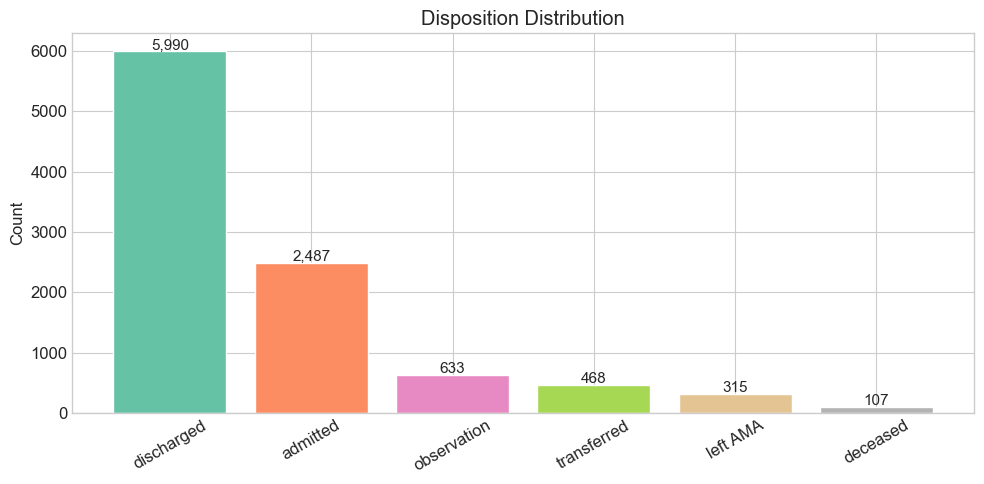

In [15]:
# Disposition distribution
disp_counts = encounters['disposition'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(disp_counts.index, disp_counts.values,
       color=plt.cm.Set2(np.linspace(0, 1, len(disp_counts))), edgecolor='white')
for i, val in enumerate(disp_counts.values):
    ax.text(i, val + 30, f"{val:,}", ha='center', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('Disposition Distribution')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 🔗 Cross-Table Analysis

The real power of this dataset is in connecting tables. Let’s merge patients with their encounters and look at utilization patterns.

In [16]:
# Merge patients with encounters
patient_encounters = merge_patient_encounters(patients, encounters)
print(f"Merged dataset: {len(patient_encounters):,} rows x {len(patient_encounters.columns)} columns")
patient_encounters.head(3)

Merged dataset: 10,000 rows x 25 columns


,encounter_id,patient_id,encounter_date,encounter_type,facility,chief_complaint,diagnosis_code,diagnosis_description,triage_level,disposition,...,date_of_birth,age,sex,postal_code,blood_type,insurance_number,primary_language,emergency_contact_phone,fsa,patient_age_at_encounter
0,ENC-0000001,PAT-000797,2024-10-28,outpatient,Royal Jubilee Hospital,nausea and vomiting,K21.0,Gastroesophageal reflux disease,2,discharged,...,1962-03-10,64,F,V8T 7B3,O+,0252 287 084,English,755-044-8177,V8T,62.6
1,ENC-0000002,PAT-001385,2025-03-21,emergency,Saanich Peninsula Hospital,cough and cold symptoms,J06.9,Acute upper respiratory infection,4,discharged,...,2016-05-03,9,M,V8S 6E2,A+,8529 309 082,English,(808) 157-1290 x150,V8S,8.9
2,ENC-0000003,PAT-001668,2023-04-12,outpatient,Royal Jubilee Hospital,dizziness,E11.9,Type 2 diabetes mellitus,3,discharged,...,1981-02-15,45,M,V8S 0G4,O+,5083 767 211,English,(526) 118-9003,V8S,42.2


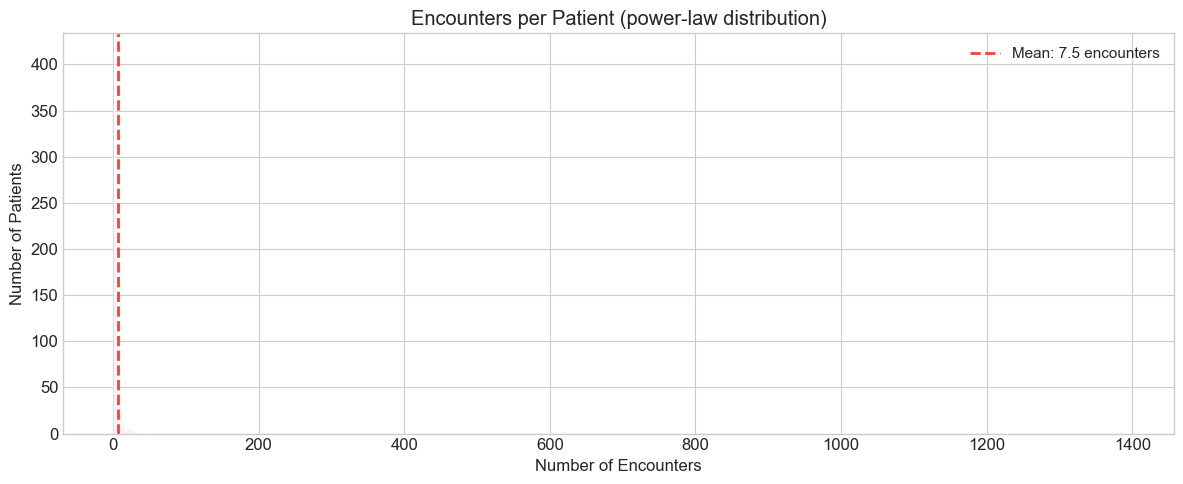

In [17]:
# Average encounters per patient
enc_per_patient = encounters.groupby('patient_id').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(enc_per_patient.values, bins=range(1, enc_per_patient.max() + 2),
        color='#7E57C2', edgecolor='white', alpha=0.85)
ax.axvline(enc_per_patient.mean(), color='#F44336', linestyle='--', linewidth=2,
           label=f"Mean: {enc_per_patient.mean():.1f} encounters")
ax.set_xlabel('Number of Encounters')
ax.set_ylabel('Number of Patients')
ax.set_title('Encounters per Patient (power-law distribution)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
# Top 10 patients by encounter count ("frequent flyers")
top_patients = enc_per_patient.sort_values(ascending=False).head(10).reset_index()
top_patients.columns = ['patient_id', 'encounter_count']
top_patients = top_patients.merge(patients[['patient_id', 'age', 'sex']], on='patient_id')
print("Top 10 patients by encounter volume:")
top_patients

Top 10 patients by encounter volume:


,patient_id,encounter_count,age,sex
0,PAT-001894,1387,1,F
1,PAT-001997,325,51,M
2,PAT-001918,309,65,M
3,PAT-000008,222,38,F
4,PAT-001421,219,40,M
5,PAT-001058,204,53,M
6,PAT-000164,153,28,F
7,PAT-001947,136,29,F
8,PAT-001668,105,45,M
9,PAT-001191,78,75,F


In [19]:
# High-risk patients (3+ conditions OR 5+ active meds)
high_risk = get_high_risk_patients(patients, encounters, medications)
high_risk.head(10)

Found 693 high-risk patients (34.6% of all patients)
  Criteria: >= 3 conditions OR >= 5 active meds


,patient_id,first_name,last_name,date_of_birth,age,sex,postal_code,blood_type,insurance_number,primary_language,emergency_contact_phone,fsa,total_encounters,unique_diagnoses,diagnosis_list,last_encounter_date,most_common_facility,active_medications,medication_list
0,PAT-001894,Monica,Chavez,2024-11-27,1,F,V8X 5L7,O+,1814 848 475,English,(763) 094-4238,V8X,1387,50,"Acute myocardial infarction, Acute upper respi...",2026-03-13,Royal Jubilee Hospital,0,
1,PAT-001997,Michael,Howard,1974-12-31,51,M,V8T 6S3,O+,9008 847 819,English,689 860 6106,V8T,325,46,"Type 2 diabetes mellitus, Allergic rhinitis du...",2026-03-13,Royal Jubilee Hospital,1,pantoprazole
2,PAT-001918,Jose,Page,1960-05-23,65,M,V8V 2W0,O+,2599 974 726,French,1-540-458-8311,V8V,309,44,"Fracture of lower end of radius, Essential hyp...",2026-03-13,Royal Jubilee Hospital,2,"prednisone, sertraline"
3,PAT-001058,Austin,Higgins,1972-11-30,53,M,V8N 0J4,O+,3425 399 650,English,1-909-762-6374,V8N,204,41,"Calculus of kidney, Major depressive disorder,...",2026-03-13,Royal Jubilee Hospital,2,"furosemide, acetaminophen"
4,PAT-000008,Danielle,Hoffman,1987-12-01,38,F,V9B 7R5,B+,3285 389 354,Mandarin,1-296-965-3287,V9B,222,41,"Abdominal pain, unspecified, Allergic rhinitis...",2026-03-03,Royal Jubilee Hospital,2,"sitagliptin, metoprolol"
5,PAT-001421,William,Holland,1986-02-01,40,M,V9A 2T6,A+,1078 901 836,English,189.455.9067,V9A,219,38,"Pneumonia, unspecified, Open wound of finger, ...",2026-03-14,Royal Jubilee Hospital,2,"sitagliptin, sertraline"
6,PAT-000164,Tammy,Barron,1997-08-24,28,F,V9B 5G6,A-,0415 549 540,English,1-814-593-3272,V9B,153,37,"Headache, Acute upper respiratory infection, P...",2026-03-11,Royal Jubilee Hospital,1,prednisone
7,PAT-001792,Michael,Hughes,1981-07-10,44,M,V8W 9Y4,A+,9583 977 081,English,(168) 154-1858,V8W,74,34,"Chest pain, unspecified, Pneumonia, unspecifie...",2026-03-09,Royal Jubilee Hospital,4,"pantoprazole, omeprazole, acetaminophen, azith..."
8,PAT-001947,Carol,Yang,1996-12-21,29,F,V9A 7A2,A+,8060 247 495,English,242.066.7015,V9A,136,33,"Urinary tract infection, Essential hypertensio...",2026-03-13,Royal Jubilee Hospital,1,prednisone
9,PAT-001668,Adrian,Collier,1981-02-15,45,M,V8S 0G4,O+,5083 767 211,English,(526) 118-9003,V8S,105,31,"Type 2 diabetes mellitus, Major depressive dis...",2026-03-12,Royal Jubilee Hospital,1,pantoprazole


In [20]:
# 30-day readmission rate
readmit = calculate_readmission_rate(encounters, window_days=30)
readmit.head(10)

30-day readmission rate: 25.9%
  645 readmissions out of 2,487 inpatient encounters


,patient_id,index_encounter_id,index_discharge_date,readmission_encounter_id,readmission_date,days_to_readmission,was_readmitted
0,PAT-000001,ENC-0003246,2024-09-10 07:12:00,NaN,NaT,NaN,False
1,PAT-000004,ENC-0008677,2025-10-06 14:24:00,NaN,NaT,NaN,False
2,PAT-000006,ENC-0001817,2025-09-27 00:00:00,NaN,NaT,NaN,False
3,PAT-000007,ENC-0002661,2024-06-15 00:00:00,NaN,NaT,NaN,False
4,PAT-000008,ENC-0000456,2023-01-11 06:30:00,NaN,NaT,NaN,False
5,PAT-000008,ENC-0009117,2023-01-12 00:00:00,NaN,NaT,NaN,False
6,PAT-000008,ENC-0007887,2023-03-10 04:06:00,ENC-0005005,2023-03-13,2.0,True
7,PAT-000008,ENC-0005005,2023-03-14 14:12:00,ENC-0009361,2023-03-19,4.0,True
8,PAT-000008,ENC-0009361,2023-03-22 14:24:00,ENC-0007234,2023-04-12,20.0,True
9,PAT-000008,ENC-0007234,2023-04-13 22:06:00,ENC-0008499,2023-04-18,4.0,True


---
## 🧪 Lab Results & Vitals

The synthetic lab and vitals data is **medically correlated** with diagnoses — diabetic patients have elevated glucose, MI patients have elevated troponin, hypertensive patients have high BP. This is what makes the data useful for ML.

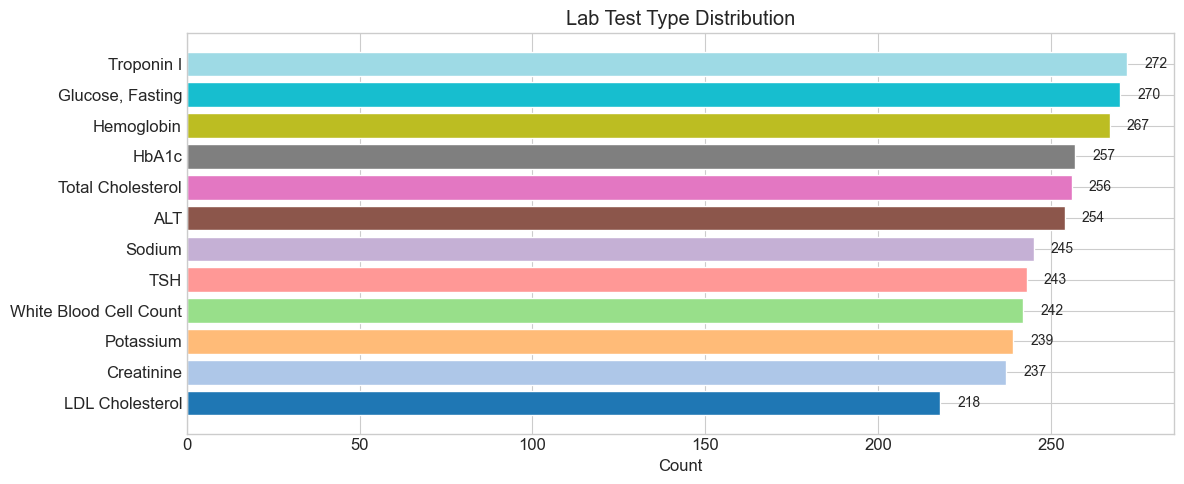

In [21]:
# Distribution of lab test types
test_counts = labs['test_name'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(test_counts.index[::-1], test_counts.values[::-1],
        color=plt.cm.tab20(np.linspace(0, 1, len(test_counts))), edgecolor='white')
for i, val in enumerate(test_counts.values[::-1]):
    ax.text(val + 5, i, f"{val:,}", va='center', fontsize=10)
ax.set_xlabel('Count')
ax.set_title('Lab Test Type Distribution')
plt.tight_layout()
plt.show()

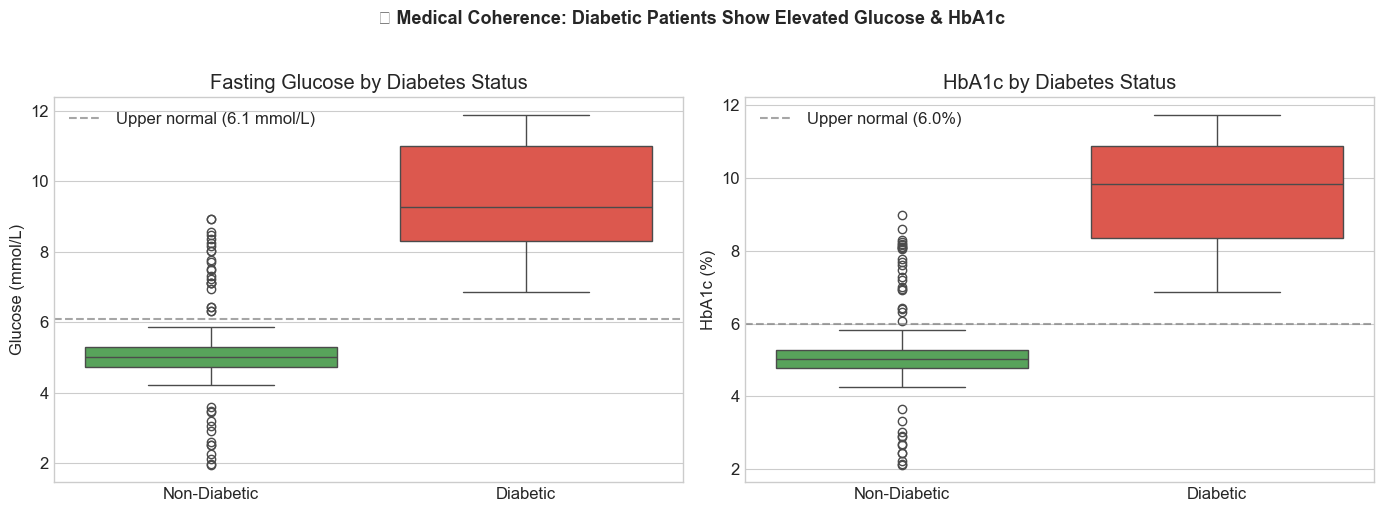

In [22]:
# Correlation: Diabetes diagnosis → elevated glucose & HbA1c
# Tag each lab result's encounter with its diagnosis
labs_with_dx = labs.merge(
    encounters[['encounter_id', 'diagnosis_code']], on='encounter_id', how='left'
)

# Glucose comparison: diabetic (E11.9) vs non-diabetic encounters
glucose = labs_with_dx[labs_with_dx['test_code'] == '1558-6'].copy()
glucose['diabetic'] = glucose['diagnosis_code'].eq('E11.9').map({True: 'Diabetic', False: 'Non-Diabetic'})

hba1c = labs_with_dx[labs_with_dx['test_code'] == '4548-4'].copy()
hba1c['diabetic'] = hba1c['diagnosis_code'].eq('E11.9').map({True: 'Diabetic', False: 'Non-Diabetic'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=glucose, x='diabetic', y='value', palette=['#4CAF50', '#F44336'], ax=axes[0])
axes[0].axhline(6.1, color='gray', linestyle='--', alpha=0.7, label='Upper normal (6.1 mmol/L)')
axes[0].set_title('Fasting Glucose by Diabetes Status')
axes[0].set_ylabel('Glucose (mmol/L)')
axes[0].set_xlabel('')
axes[0].legend()

sns.boxplot(data=hba1c, x='diabetic', y='value', palette=['#4CAF50', '#F44336'], ax=axes[1])
axes[1].axhline(6.0, color='gray', linestyle='--', alpha=0.7, label='Upper normal (6.0%)')
axes[1].set_title('HbA1c by Diabetes Status')
axes[1].set_ylabel('HbA1c (%)')
axes[1].set_xlabel('')
axes[1].legend()

plt.suptitle('🔍 Medical Coherence: Diabetic Patients Show Elevated Glucose & HbA1c',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

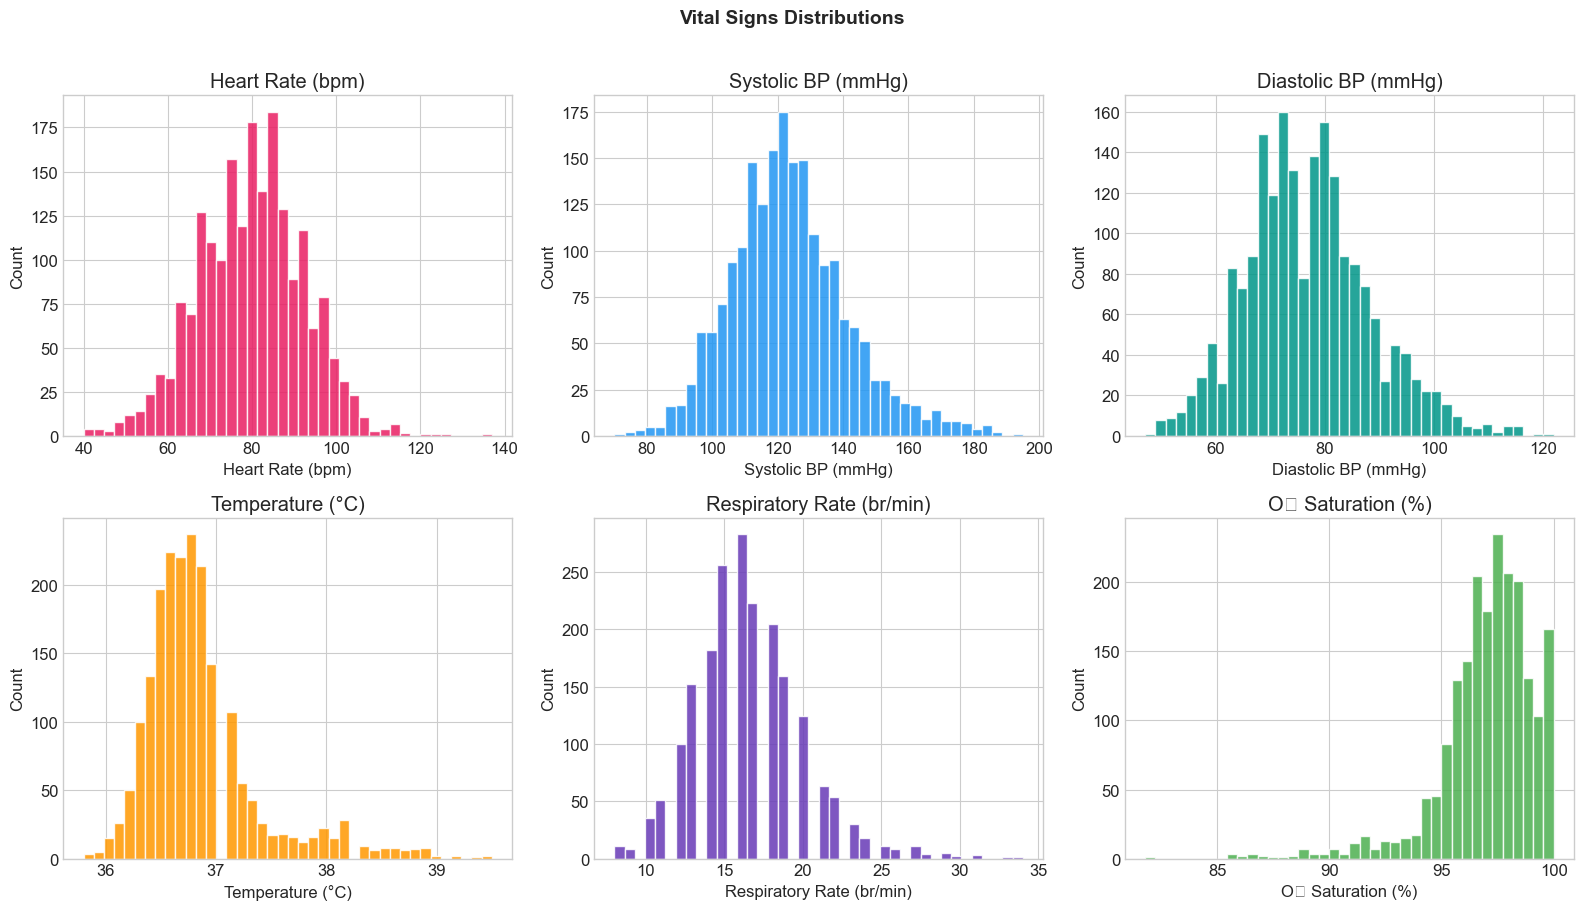

In [23]:
# Vitals distributions
vitals_cols = ['heart_rate', 'systolic_bp', 'diastolic_bp',
               'temperature_celsius', 'respiratory_rate', 'o2_saturation']
vitals_labels = ['Heart Rate (bpm)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)',
                 'Temperature (°C)', 'Respiratory Rate (br/min)', 'O₂ Saturation (%)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors = ['#E91E63', '#2196F3', '#009688', '#FF9800', '#673AB7', '#4CAF50']

for ax, col, label, color in zip(axes.flat, vitals_cols, vitals_labels, colors):
    ax.hist(vitals[col].dropna(), bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)

plt.suptitle('Vital Signs Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

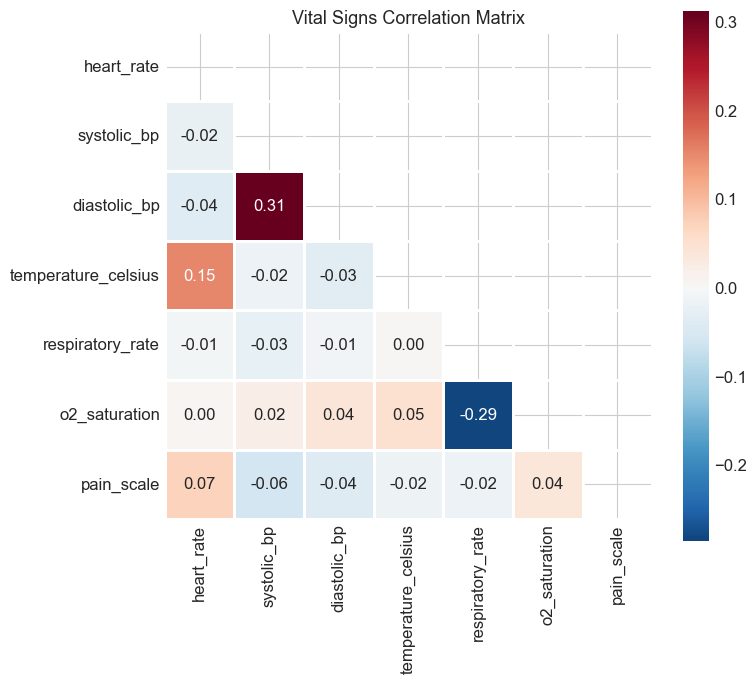

In [24]:
# Correlation heatmap of vitals
vitals_numeric = vitals[['heart_rate', 'systolic_bp', 'diastolic_bp',
                         'temperature_celsius', 'respiratory_rate',
                         'o2_saturation', 'pain_scale']]

fig, ax = plt.subplots(figsize=(8, 7))
corr = vitals_numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Vital Signs Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

---
## 🤖 Challenge: Predict Triage Level (CTAS)

Can we predict how urgently a patient needs care based on their clinical presentation?

**Target:** `triage_level` (CTAS 1–5, where 1 = most urgent)

**Features we’ll use:**
- Chief complaint (text → encoded)
- Vital signs (heart rate, BP, temperature, O₂ sat, respiratory rate)
- Patient age and sex
- Encounter type

This is a real clinical problem — automated triage could help reduce wait times in BC emergency departments.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Merge data: patients + encounters + vitals
model_data = merge_patient_encounters(patients, encounters)
model_data = merge_encounter_vitals(model_data, vitals)

# Keep only rows that have vitals (our vitals dataset is smaller)
model_data = model_data.dropna(subset=['heart_rate', 'systolic_bp', 'o2_saturation'])
print(f"Training samples with complete data: {len(model_data):,}")

Training samples with complete data: 1,788


In [26]:
# Feature engineering
# Encode chief complaint
le_complaint = LabelEncoder()
model_data['complaint_encoded'] = le_complaint.fit_transform(
    model_data['chief_complaint'].fillna('unknown')
)

# Encode sex
model_data['sex_encoded'] = (model_data['sex'] == 'F').astype(int)

# Encode encounter type
le_encounter = LabelEncoder()
model_data['encounter_type_encoded'] = le_encounter.fit_transform(
    model_data['encounter_type']
)

# Select features
feature_cols = [
    'complaint_encoded', 'sex_encoded', 'age', 'encounter_type_encoded',
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'temperature_celsius',
    'respiratory_rate', 'o2_saturation', 'pain_scale'
]

X = model_data[feature_cols].fillna(0)
y = model_data['triage_level']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {len(X_train):,} | Test set: {len(X_test):,}")

Training set: 1,430 | Test set: 358


In [27]:
# Train a Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[f"CTAS {i}" for i in sorted(y.unique())]
))

Random Forest Results:
Accuracy: 0.310

Classification Report:
              precision    recall  f1-score   support

      CTAS 1       0.00      0.00      0.00        15
      CTAS 2       0.14      0.02      0.03        51
      CTAS 3       0.35      0.63      0.45       133
      CTAS 4       0.24      0.24      0.24       108
      CTAS 5       0.00      0.00      0.00        51

    accuracy                           0.31       358
   macro avg       0.15      0.18      0.15       358
weighted avg       0.22      0.31      0.25       358



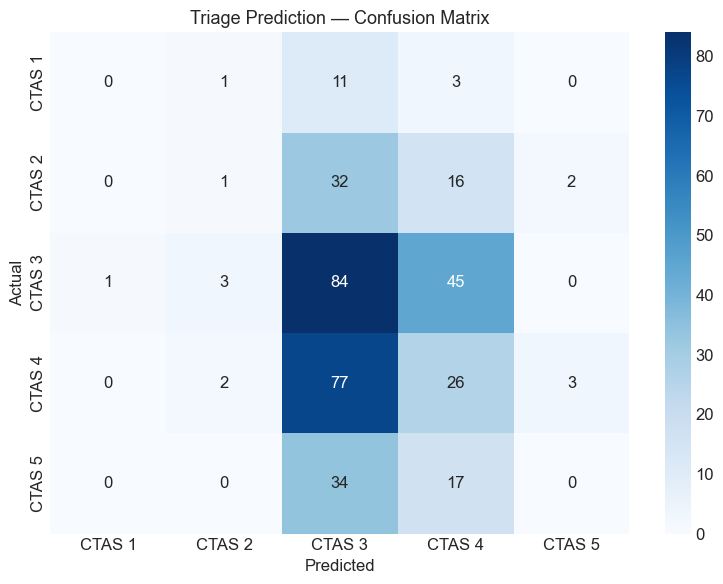

In [28]:
# Confusion matrix visualization
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"CTAS {i}" for i in sorted(y.unique())],
            yticklabels=[f"CTAS {i}" for i in sorted(y.unique())],
            ax=ax)
ax.set_title('Triage Prediction — Confusion Matrix', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

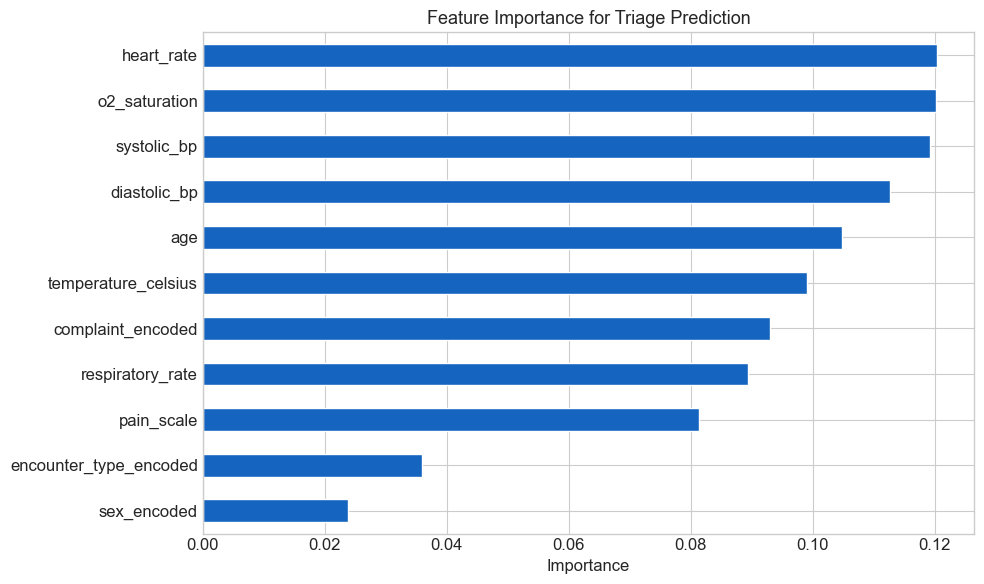

In [29]:
# Feature importance
importances = pd.Series(
    rf.feature_importances_, index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', color='#1565C0', edgecolor='white', ax=ax)
ax.set_title('Feature Importance for Triage Prediction', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### Try Gradient Boosting (optional comparison)

In [30]:
# Gradient Boosting for comparison
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.3f}")
print(f"\n(vs. Random Forest: {accuracy_score(y_test, y_pred):.3f})")

Gradient Boosting Results:
Accuracy: 0.307

(vs. Random Forest: 0.310)


---
## 🔥 Bonus: FHIR Interoperability

FHIR (Fast Healthcare Interoperability Resources) is the modern standard for exchanging healthcare data. Let’s convert our data into FHIR format — this is a great way to make your project interoperable.

In [31]:
# Convert a patient to FHIR format
fhir_patient = patient_to_fhir(patients.iloc[0])
print(json.dumps(fhir_patient, indent=2, default=str))

{
  "resourceType": "Patient",
  "id": "PAT-000001",
  "meta": {
    "profile": [
      "http://hl7.org/fhir/ca/core/StructureDefinition/profile-patient"
    ]
  },
  "identifier": [
    {
      "system": "https://hackathon.uvic.ca/patient-id",
      "value": "PAT-000001"
    },
    {
      "type": {
        "coding": [
          {
            "system": "http://terminology.hl7.org/CodeSystem/v2-0203",
            "code": "JHN",
            "display": "Jurisdictional health number"
          }
        ]
      },
      "system": "https://www2.gov.bc.ca/gov/content/health/health-drug-coverage/msp",
      "value": "2074 916 154"
    }
  ],
  "name": [
    {
      "use": "official",
      "family": "Johnson",
      "given": [
        "Margaret"
      ]
    }
  ],
  "gender": "female",
  "birthDate": "1974-09-22",
  "address": [
    {
      "use": "home",
      "city": "Victoria",
      "state": "BC",
      "postalCode": "V8S 6G3",
      "country": "CA"
    }
  ],
  "communication": [
    {


In [32]:
# Convert encounters to a FHIR Bundle
sample_encounters = encounters.head(5)
fhir_encounters = [encounter_to_fhir(row) for _, row in sample_encounters.iterrows()]
bundle = batch_to_fhir_bundle(fhir_encounters, "Encounter")

print(f"Created FHIR Bundle with {bundle['total']} encounters")
print(json.dumps(bundle['entry'][0], indent=2, default=str))

Created FHIR Bundle with 5 encounters
{
  "fullUrl": "urn:uuid:ENC-0000001",
  "resource": {
    "resourceType": "Encounter",
    "id": "ENC-0000001",
    "status": "finished",
    "class": {
      "system": "http://terminology.hl7.org/CodeSystem/v3-ActCode",
      "code": "AMB",
      "display": "ambulatory"
    },
    "subject": {
      "reference": "Patient/PAT-000797"
    },
    "period": {
      "start": "2024-10-28"
    },
    "reasonCode": [
      {
        "coding": [
          {
            "system": "http://hl7.org/fhir/sid/icd-10-ca",
            "code": "K21.0",
            "display": "Gastroesophageal reflux disease"
          }
        ]
      }
    ],
    "priority": {
      "coding": [
        {
          "system": "https://www.ctas-phctas.ca",
          "code": "2",
          "display": "CTAS Level 2"
        }
      ]
    },
    "serviceProvider": {
      "display": "Royal Jubilee Hospital"
    }
  }
}


---
## 💡 Project Ideas — Where to Go from Here

Now that you have the basics, here are ideas to build a hackathon-winning project:

### Triage Optimization
- Add NLP features by processing chief complaint text with embeddings
- Incorporate lab results and medication history for more accurate predictions
- Build a real-time triage dashboard with Streamlit or Gradio

### Clinical Decision Support
- Build a medication interaction checker using the drug reference database
- Create a diagnostic suggestion tool based on symptoms, vitals, and labs
- Develop an early warning system for patient deterioration (NEWS2 score)

### Patient Flow & Operations
- Predict length of stay from admission features
- Model ED wait times and suggest optimal staffing
- Build a bed management dashboard for Royal Jubilee Hospital

### FHIR Integration
- Connect to the HAPI FHIR sandbox (`http://hapi.fhir.org/baseR4`) for live API testing
- Build a FHIR-native patient portal
- Create a clinical data exchange demo between two FHIR servers

### Resources
- **HAPI FHIR Test Server:** `http://hapi.fhir.org/baseR4`
- **CMS Blue Button Sandbox:** `https://sandbox.bluebutton.cms.gov`
- **FHIR R4 Documentation:** `https://hl7.org/fhir/R4/`
- **MedMNIST for medical imaging:** `pip install medmnist`

**Good luck and happy hacking! 🚀**